In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('../pipeline_data/cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

# print(df_clean.shape)
# print(df_clean.dtypes)
# print(df_clean.head(3).to_string())

Loaded data: 37,008 quotes from 25,716 customers


segment
BOILER_GAS → BOILER_GAS              6546
STOVE → STOVE                        5727
AIR_CONDITIONER → AIR_CONDITIONER    4794
HEAT_PUMP → HEAT_PUMP                3927
OTHER → OTHER                        2429
HEAT_PUMP → OTHER                     275
OTHER → HEAT_PUMP                     224
BOILER_GAS → HEAT_PUMP                215
HEAT_PUMP → STOVE                     182
BOILER_GAS → OTHER                    142
AIR_CONDITIONER → HEAT_PUMP           136
AIR_CONDITIONER → OTHER               124
HEAT_PUMP → BOILER_GAS                120
BOILER_GAS → AIR_CONDITIONER          115
OTHER → STOVE                         105
OTHER → AIR_CONDITIONER                94
OTHER → BOILER_GAS                     88
AIR_CONDITIONER → STOVE                88
HEAT_PUMP → AIR_CONDITIONER            83
STOVE → HEAT_PUMP                      81
STOVE → OTHER                          73
STOVE → AIR_CONDITIONER                45
AIR_CONDITIONER → BOILER_GAS           44
BOILER_GAS → STOVE        

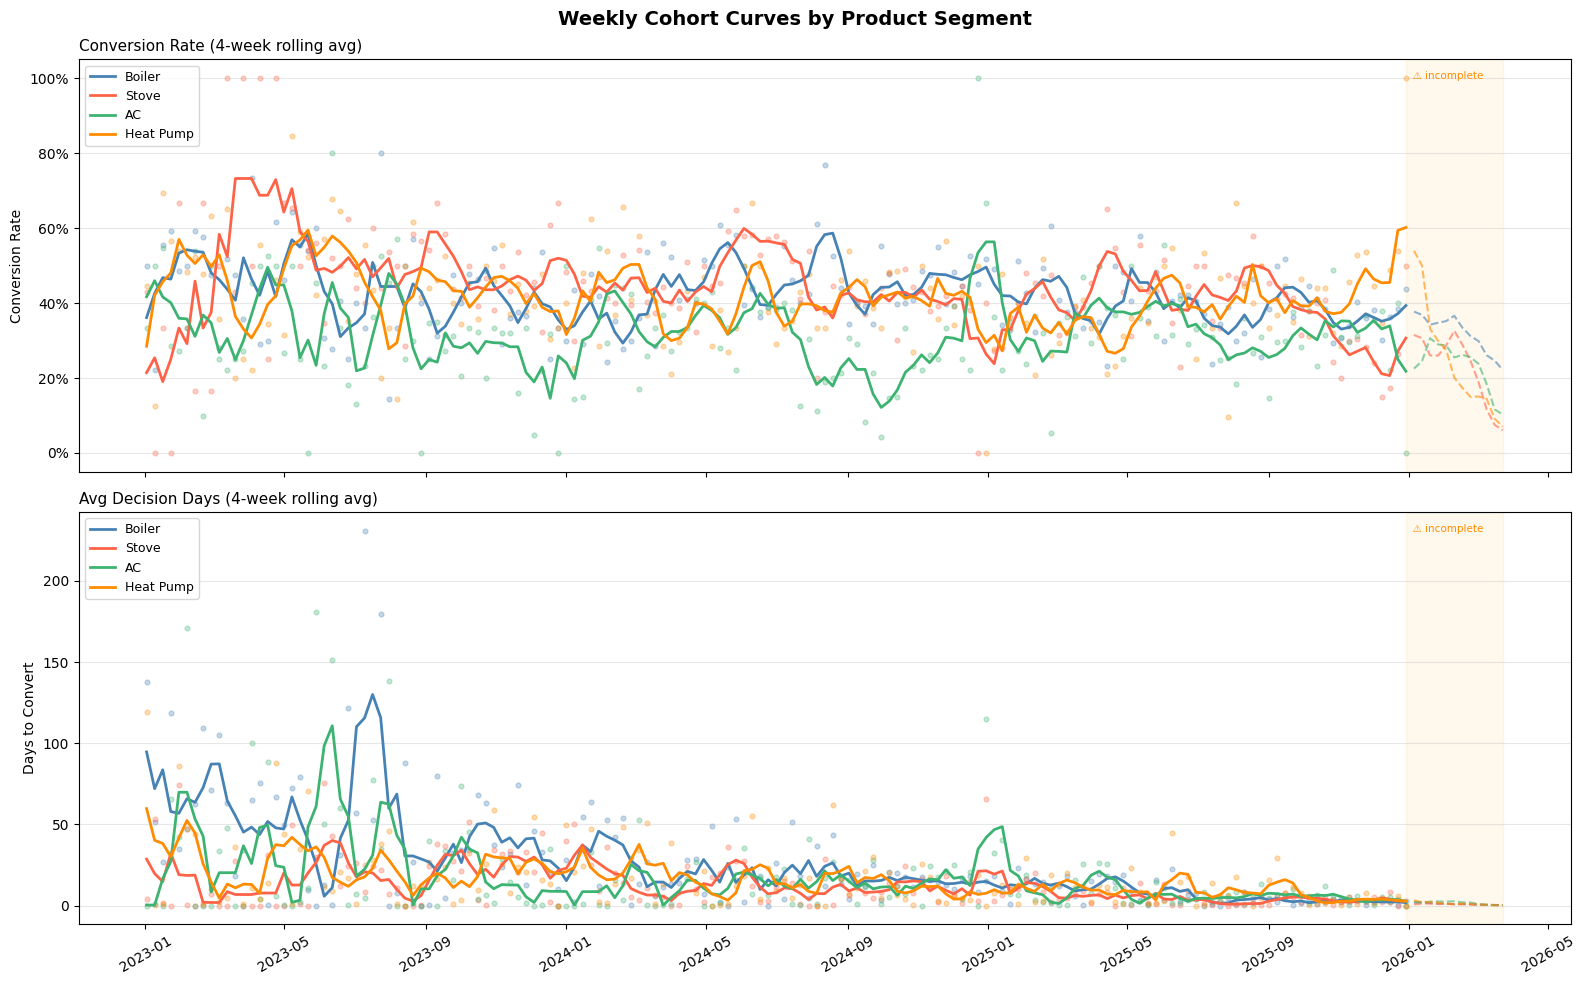

In [3]:
from cohort_curves import plot_cohort_curves
plot_cohort_curves(df_clean)

In [ ]:
# Sort by customer and date
df_sorted = df_clean.sort_values(['numero_compte', 'dt_creation_devis'])

# First and last product per customer
journey = df_sorted.groupby('numero_compte').agg(
    first_quote_date=('dt_creation_devis', 'first'),
    last_quote_date=('dt_creation_devis', 'last'),
    first_product=('regroup_famille_equipement_produit_principal', 'first'),
    last_product=('regroup_famille_equipement_produit_principal', 'last'),
    converted=('fg_devis_accepte', 'max'),
    total_quotes=('id_devis', 'count'),
    decision_days=('dt_creation_devis', lambda x: (x.max() - x.min()).days)
).reset_index()

# Build journey label
journey['segment'] = journey['first_product'] + ' → ' + journey['last_product']

# Summary
print(journey['segment'].value_counts())
print(f"\nTotal customers: {len(journey):,}")
print(f"Multi-product journeys: {(journey['first_product'] != journey['last_product']).sum():,}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Focus on the 4 main diagonal segments
main_segments = ['BOILER_GAS → BOILER_GAS', 'STOVE → STOVE', 
                 'AIR_CONDITIONER → AIR_CONDITIONER', 'HEAT_PUMP → HEAT_PUMP']

labels = {
    'BOILER_GAS → BOILER_GAS':                'Boiler',
    'STOVE → STOVE':                          'Stove',
    'AIR_CONDITIONER → AIR_CONDITIONER':      'AC',
    'HEAT_PUMP → HEAT_PUMP':                  'Heat Pump'
}

# Build weekly cohorts per segment
journey['cohort_week'] = journey['first_quote_date'].dt.to_period('W').dt.start_time
journey['year']        = journey['first_quote_date'].dt.year

cohort_seg = (
    journey[journey['segment'].isin(main_segments)]
    .groupby(['segment', 'cohort_week'])
    .agg(
        total=('numero_compte', 'count'),
        converted=('converted', 'sum'),
        avg_decision_days=('decision_days', 'mean')
    )
    .reset_index()
)
cohort_seg['conversion_rate'] = cohort_seg['converted'] / cohort_seg['total'] * 100

# Rolling average (4-week) per segment
cohort_seg = cohort_seg.sort_values(['segment', 'cohort_week'])
cohort_seg['conv_roll4'] = (
    cohort_seg.groupby('segment')['conversion_rate']
    .transform(lambda x: x.rolling(4, center=True, min_periods=2).mean())
)
cohort_seg['days_roll4'] = (
    cohort_seg.groupby('segment')['avg_decision_days']
    .transform(lambda x: x.rolling(4, center=True, min_periods=2).mean())
)

# Mark incomplete cohorts (last 12 weeks)
cutoff = journey['cohort_week'].max() - pd.Timedelta(weeks=12)
cohort_seg['incomplete'] = cohort_seg['cohort_week'] > cutoff

colors = {
    'BOILER_GAS → BOILER_GAS':            'steelblue',
    'STOVE → STOVE':                      'tomato',
    'AIR_CONDITIONER → AIR_CONDITIONER':  'mediumseagreen',
    'HEAT_PUMP → HEAT_PUMP':              'darkorange'
}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Weekly Cohort Curves by Product Segment', fontsize=14, fontweight='bold')

for seg in main_segments:
    data      = cohort_seg[cohort_seg['segment'] == seg]
    complete  = data[~data['incomplete']]
    incompl   = data[data['incomplete']]
    color     = colors[seg]
    label     = labels[seg]

    for ax, metric, roll in zip(axes, ['conversion_rate', 'avg_decision_days'], ['conv_roll4', 'days_roll4']):
        # Raw dots
        ax.scatter(complete['cohort_week'], complete[metric],
                   s=12, alpha=0.3, color=color)
        # Rolling avg — complete
        ax.plot(complete['cohort_week'], complete[roll],
                color=color, linewidth=2, label=label)
        # Rolling avg — incomplete (dashed)
        ax.plot(incompl['cohort_week'], incompl[roll],
                color=color, linewidth=1.5, linestyle='--', alpha=0.6)

# Panel 1: Conversion rate
axes[0].set_title('Conversion Rate (4-week rolling avg)', fontsize=11, loc='left')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(labelbottom=False)

# Panel 2: Decision days
axes[1].set_title('Avg Decision Days (4-week rolling avg)', fontsize=11, loc='left')
axes[1].set_ylabel('Days to Convert')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

# Shade incomplete zone on both panels
for ax in axes:
    ax.axvspan(cutoff, journey['cohort_week'].max(),
               alpha=0.07, color='orange')
    ax.text(cutoff, ax.get_ylim()[1] * 0.97, '  ⚠ incomplete',
            fontsize=7.5, color='darkorange', va='top')

plt.tight_layout()
plt.savefig('cohort_curves_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Switcher segments with >50 customers
switchers = journey[journey['first_product'] != journey['last_product']].copy()

# Filter meaningful segments
switcher_counts = switchers['segment'].value_counts()
meaningful = switcher_counts[switcher_counts > 50].index.tolist()

print(switcher_counts[switcher_counts > 50])
print(f"\nTotal switcher segments to plot: {len(meaningful)}")

# Build weekly cohorts per switcher segment
switchers['cohort_week'] = switchers['first_quote_date'].dt.to_period('W').dt.start_time

cohort_sw = (
    switchers[switchers['segment'].isin(meaningful)]
    .groupby(['segment', 'cohort_week'])
    .agg(
        total=('numero_compte', 'count'),
        converted=('converted', 'sum'),
        avg_decision_days=('decision_days', 'mean')
    )
    .reset_index()
)
cohort_sw['conversion_rate'] = cohort_sw['converted'] / cohort_sw['total'] * 100

# Rolling average
cohort_sw = cohort_sw.sort_values(['segment', 'cohort_week'])
cohort_sw['conv_roll4'] = (
    cohort_sw.groupby('segment')['conversion_rate']
    .transform(lambda x: x.rolling(4, center=True, min_periods=2).mean())
)
cohort_sw['days_roll4'] = (
    cohort_sw.groupby('segment')['avg_decision_days']
    .transform(lambda x: x.rolling(4, center=True, min_periods=2).mean())
)

cohort_sw['incomplete'] = cohort_sw['cohort_week'] > cutoff

# Dynamic color palette
import matplotlib.cm as cm
palette = cm.tab10.colors
seg_colors = {seg: palette[i % 10] for i, seg in enumerate(meaningful)}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Weekly Cohort Curves — Switcher Segments', fontsize=14, fontweight='bold')

for seg in meaningful:
    data     = cohort_sw[cohort_sw['segment'] == seg]
    complete = data[~data['incomplete']]
    incompl  = data[data['incomplete']]
    color    = seg_colors[seg]

    for ax, metric, roll in zip(axes, ['conversion_rate', 'avg_decision_days'], ['conv_roll4', 'days_roll4']):
        ax.scatter(complete['cohort_week'], complete[metric],
                   s=12, alpha=0.25, color=color)
        ax.plot(complete['cohort_week'], complete[roll],
                color=color, linewidth=2, label=seg.replace('_', ' '))
        ax.plot(incompl['cohort_week'], incompl[roll],
                color=color, linewidth=1.5, linestyle='--', alpha=0.6)

axes[0].set_title('Conversion Rate (4-week rolling avg)', fontsize=11, loc='left')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(fontsize=7.5, ncol=2)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(labelbottom=False)

axes[1].set_title('Avg Decision Days (4-week rolling avg)', fontsize=11, loc='left')
axes[1].set_ylabel('Days to Convert')
axes[1].legend(fontsize=7.5, ncol=2)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.axvspan(cutoff, journey['cohort_week'].max(), alpha=0.07, color='orange')
    ax.text(cutoff, ax.get_ylim()[1] * 0.97, '  ⚠ incomplete',
            fontsize=7.5, color='darkorange', va='top')

plt.tight_layout()
plt.savefig('cohort_curves_switchers.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Top 4 switcher segments only
top_switchers = [
    'HEAT_PUMP → OTHER',
    'OTHER → HEAT_PUMP',
    'BOILER_GAS → HEAT_PUMP',
    'HEAT_PUMP → STOVE'
]

# Monthly cohorts
switchers['cohort_month'] = switchers['first_quote_date'].dt.to_period('M').dt.start_time

cohort_sw_m = (
    switchers[switchers['segment'].isin(top_switchers)]
    .groupby(['segment', 'cohort_month'])
    .agg(
        total=('numero_compte', 'count'),
        converted=('converted', 'sum'),
        avg_decision_days=('decision_days', 'mean')
    )
    .reset_index()
)
cohort_sw_m['conversion_rate'] = cohort_sw_m['converted'] / cohort_sw_m['total'] * 100

# Rolling avg (3-month)
cohort_sw_m = cohort_sw_m.sort_values(['segment', 'cohort_month'])
cohort_sw_m['conv_roll3'] = (
    cohort_sw_m.groupby('segment')['conversion_rate']
    .transform(lambda x: x.rolling(3, center=True, min_periods=2).mean())
)
cohort_sw_m['days_roll3'] = (
    cohort_sw_m.groupby('segment')['avg_decision_days']
    .transform(lambda x: x.rolling(3, center=True, min_periods=2).mean())
)

# Incomplete = last 3 months
cutoff_m = switchers['cohort_month'].max() - pd.DateOffset(months=3)
cohort_sw_m['incomplete'] = cohort_sw_m['cohort_month'] > cutoff_m

colors_sw = {
    'HEAT_PUMP → OTHER':       'darkorange',
    'OTHER → HEAT_PUMP':       'steelblue',
    'BOILER_GAS → HEAT_PUMP':  'mediumseagreen',
    'HEAT_PUMP → STOVE':       'tomato'
}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Monthly Cohort Curves — Top 4 Switcher Segments', fontsize=14, fontweight='bold')

for seg in top_switchers:
    data     = cohort_sw_m[cohort_sw_m['segment'] == seg]
    complete = data[~data['incomplete']]
    incompl  = data[data['incomplete']]
    color    = colors_sw[seg]
    label    = seg.replace('_', ' ')
    n        = int(switchers[switchers['segment'] == seg]['numero_compte'].count())

    for ax, metric, roll in zip(axes,
                                ['conversion_rate', 'avg_decision_days'],
                                ['conv_roll3', 'days_roll3']):
        ax.scatter(complete['cohort_month'], complete[metric],
                   s=25, alpha=0.35, color=color)
        ax.plot(complete['cohort_month'], complete[roll],
                color=color, linewidth=2.2, label=f'{label}  (n={n})')
        ax.plot(incompl['cohort_month'], incompl[roll],
                color=color, linewidth=1.5, linestyle='--', alpha=0.6)

axes[0].set_title('Conversion Rate (3-month rolling avg)', fontsize=11, loc='left')
axes[0].set_ylabel('Conversion Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(labelbottom=False)

axes[1].set_title('Avg Decision Days (3-month rolling avg)', fontsize=11, loc='left')
axes[1].set_ylabel('Days to Convert')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.axvspan(cutoff_m, switchers['cohort_month'].max(),
               alpha=0.07, color='orange')
    ax.text(cutoff_m, ax.get_ylim()[1] * 0.97, '  ⚠ incomplete',
            fontsize=7.5, color='darkorange', va='top')

plt.tight_layout()
plt.savefig('cohort_curves_top_switchers.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Assign quarter label
for d in [journey, switchers]:
    d['quarter_label'] = d['first_quote_date'].dt.year.astype(str) + ' Q' + d['first_quote_date'].dt.quarter.astype(str)

# Filter to 2025 Q1-Q4 and 2026 Q1
quarters_to_plot = ['2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1']

# ── Diagonal segments ─────────────────────────────────────────────────────────
diag_q = (
    journey[journey['segment'].isin(main_segments) & journey['quarter_label'].isin(quarters_to_plot)]
    .groupby(['segment', 'quarter_label'])
    .agg(total=('numero_compte', 'count'),
         converted=('converted', 'sum'),
         avg_decision_days=('decision_days', 'mean'))
    .reset_index()
)
diag_q['conversion_rate'] = diag_q['converted'] / diag_q['total'] * 100

# ── Switcher segments ─────────────────────────────────────────────────────────
sw_q = (
    switchers[switchers['segment'].isin(top_switchers) & switchers['quarter_label'].isin(quarters_to_plot)]
    .groupby(['segment', 'quarter_label'])
    .agg(total=('numero_compte', 'count'),
         converted=('converted', 'sum'),
         avg_decision_days=('decision_days', 'mean'))
    .reset_index()
)
sw_q['conversion_rate'] = sw_q['converted'] / sw_q['total'] * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('Quarterly Comparison: 2025 Q1–Q4 vs 2026 Q1', fontsize=14, fontweight='bold')

diag_colors = {
    'BOILER_GAS → BOILER_GAS':           'steelblue',
    'STOVE → STOVE':                     'tomato',
    'AIR_CONDITIONER → AIR_CONDITIONER': 'mediumseagreen',
    'HEAT_PUMP → HEAT_PUMP':             'darkorange'
}
diag_labels = {
    'BOILER_GAS → BOILER_GAS':           'Boiler',
    'STOVE → STOVE':                     'Stove',
    'AIR_CONDITIONER → AIR_CONDITIONER': 'AC',
    'HEAT_PUMP → HEAT_PUMP':             'Heat Pump'
}

def plot_quarterly(ax, data, segments, colors, labels, metric, ylabel, title):
    for seg in segments:
        d = data[data['segment'] == seg].set_index('quarter_label').reindex(quarters_to_plot)
        color = colors[seg]
        label = labels[seg]
        # Shade 2026 Q1 as partial
        ax.axvspan(3.5, 4.5, alpha=0.08, color='orange')
        ax.plot(quarters_to_plot, d[metric].values, marker='o', linewidth=2.2,
                markersize=7, color=color, label=label)
        # Annotate last point
        val = d[metric].iloc[-1]
        if not pd.isna(val):
            fmt = f'{val:.0f}%' if 'rate' in metric else f'{val:.0f}d'
            ax.annotate(fmt, xy=(4, val), xytext=(4.05, val),
                        fontsize=7.5, color=color, va='center')
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
    ax.set_ylabel(ylabel)
    if 'rate' in metric:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.text(3.7, ax.get_ylim()[1] * 0.97, '⚠ partial',
            fontsize=7.5, color='darkorange', va='top')

plot_quarterly(axes[0, 0], diag_q, main_segments, diag_colors, diag_labels,
               'conversion_rate', 'Conversion Rate',
               'Diagonal — Conversion Rate')

plot_quarterly(axes[1, 0], diag_q, main_segments, diag_colors, diag_labels,
               'avg_decision_days', 'Avg Decision Days',
               'Diagonal — Decision Days')

plot_quarterly(axes[0, 1], sw_q, top_switchers, colors_sw,
               {s: s.replace('_', ' ') for s in top_switchers},
               'conversion_rate', 'Conversion Rate',
               'Switchers — Conversion Rate')

plot_quarterly(axes[1, 1], sw_q, top_switchers, colors_sw,
               {s: s.replace('_', ' ') for s in top_switchers},
               'avg_decision_days', 'Avg Decision Days',
               'Switchers — Decision Days')

plt.tight_layout()
plt.savefig('quarterly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Rebuild main_segments list from journey (consistent with switchers)
main_segments = [
    'BOILER_GAS → BOILER_GAS',
    'STOVE → STOVE',
    'AIR_CONDITIONER → AIR_CONDITIONER',
    'HEAT_PUMP → HEAT_PUMP'
]

# Reassign quarter_label on journey if not already done
journey['quarter_label'] = (
    journey['first_quote_date'].dt.year.astype(str) + ' Q' +
    journey['first_quote_date'].dt.quarter.astype(str)
)

# Rebuild diagonal quarterly cohorts from journey
diag_q = (
    journey[journey['segment'].isin(main_segments) & journey['quarter_label'].isin(quarters_to_plot)]
    .groupby(['segment', 'quarter_label'])
    .agg(total=('numero_compte', 'count'),
         converted=('converted', 'sum'),
         avg_decision_days=('decision_days', 'mean'))
    .reset_index()
)
diag_q['conversion_rate'] = diag_q['converted'] / diag_q['total'] * 100

In [ ]:
# ── Helper: assign week-within-quarter ───────────────────────────────────────
def week_in_quarter(date_series):
    quarter_start = date_series.dt.to_period('Q').dt.start_time
    return ((date_series - quarter_start) / pd.Timedelta(weeks=1)).astype(int) + 1

journey['week_in_q']   = week_in_quarter(journey['first_quote_date'])
switchers['week_in_q'] = week_in_quarter(switchers['first_quote_date'])

quarters_to_plot = ['2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1']
q_colors = {
    '2025 Q1': 'steelblue',
    '2025 Q2': 'mediumseagreen',
    '2025 Q3': 'darkorange',
    '2025 Q4': 'tomato',
    '2026 Q1': 'purple'
}

def build_intra_cohorts(df, segments, freq='W'):
    """Build weekly (stayers) or bi-weekly (switchers) within-quarter cohorts."""
    filtered = df[df['segment'].isin(segments) & df['quarter_label'].isin(quarters_to_plot)]
    if freq == 'M':
        filtered = filtered.copy()
        filtered['week_in_q'] = ((filtered['week_in_q'] - 1) // 2) + 1  # bi-weekly buckets

    return (
        filtered
        .groupby(['segment', 'quarter_label', 'week_in_q'])
        .agg(total=('numero_compte', 'count'),
             converted=('converted', 'sum'))
        .reset_index()
        .assign(conversion_rate=lambda x: x['converted'] / x['total'] * 100)
    )

diag_intra = build_intra_cohorts(journey,   main_segments, freq='W')
sw_intra   = build_intra_cohorts(switchers, top_switchers, freq='M')

def plot_intra_quarter(data, segments, labels, title_prefix, freq_label, ncols=2):
    nrows = len(segments) // ncols + len(segments) % ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharey=False)
    fig.suptitle(f'{title_prefix} — Conversion Rate Within Quarter', fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i, seg in enumerate(segments):
        ax  = axes[i]
        d   = data[data['segment'] == seg]
        label = labels[seg]

        for q in quarters_to_plot:
            qd = d[d['quarter_label'] == q].sort_values('week_in_q')
            if qd.empty:
                continue
            # smooth with rolling avg if enough points
            y = qd['conversion_rate'].rolling(2, min_periods=1).mean()
            ls = '--' if q == '2026 Q1' else '-'
            ax.plot(qd['week_in_q'], y, marker='o', linewidth=2,
                    markersize=5, color=q_colors[q], linestyle=ls, label=q)

        ax.set_title(label, fontweight='bold', fontsize=10)
        ax.set_xlabel(f'{freq_label} within quarter')
        ax.set_ylabel('Conversion Rate')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    return fig

# ── Plot stayers (weekly) ─────────────────────────────────────────────────────
fig1 = plot_intra_quarter(
    diag_intra, main_segments, diag_labels,
    title_prefix='Stayers', freq_label='Week'
)
fig1.savefig('intra_quarter_stayers.png', dpi=150, bbox_inches='tight')

# ── Plot switchers (bi-weekly) ────────────────────────────────────────────────
fig2 = plot_intra_quarter(
    sw_intra, top_switchers,
    {s: s.replace('_', ' ') for s in top_switchers},
    title_prefix='Switchers', freq_label='Bi-week'
)
fig2.savefig('intra_quarter_switchers.png', dpi=150, bbox_inches='tight')

plt.show()

In [ ]:
def plot_quarter_x_product(data, segments, labels, colors, title_prefix, freq_label, ncols=3):
    nrows = len(quarters_to_plot) // ncols + len(quarters_to_plot) % ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=False)
    fig.suptitle(f'{title_prefix} — Conversion Rate by Product Within Quarter',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i, q in enumerate(quarters_to_plot):
        ax = axes[i]
        ls = '--' if q == '2026 Q1' else '-'

        for seg in segments:
            d = data[(data['segment'] == seg) & (data['quarter_label'] == q)].sort_values('week_in_q')
            if d.empty:
                continue
            y = d['conversion_rate'].rolling(2, min_periods=1).mean()
            ax.plot(d['week_in_q'], y, marker='o', linewidth=2,
                    markersize=5, color=colors[seg], linestyle=ls,
                    label=labels[seg])

        ax.set_title(f'{q}{"  ⚠ partial" if q == "2026 Q1" else ""}',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel(f'{freq_label} within quarter')
        ax.set_ylabel('Conversion Rate')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    return fig

# Stayers — weekly
fig1 = plot_quarter_x_product(
    diag_intra, main_segments, diag_labels, diag_colors,
    title_prefix='Stayers', freq_label='Week'
)
fig1.savefig('quarter_x_product_stayers.png', dpi=150, bbox_inches='tight')

# Switchers — bi-weekly
fig2 = plot_quarter_x_product(
    sw_intra, top_switchers,
    {s: s.replace('_', ' ') for s in top_switchers},
    colors_sw,
    title_prefix='Switchers', freq_label='Bi-week'
)
fig2.savefig('quarter_x_product_switchers.png', dpi=150, bbox_inches='tight')

plt.show()